In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dropout, Dense, LSTM, Conv1D, Flatten, Concatenate, LayerNormalization, BatchNormalization
from tensorflow.keras.optimizers import Adam
import random
from collections import deque
import pandas as pd
import os
from datetime import datetime
import logging
import matplotlib.pyplot as plt

In [2]:
def create_model_directory(path_template):
    i = 1
    while True:
        path = path_template.format(i = i, date=datetime.now().strftime("%Y-%m-%d"))
        if not os.path.exists(path):
            os.makedirs(path)
            return path
        i += 1

# Usage example
path_template = './TD3_models/{date}/{i}'
model_dir = create_model_directory(path_template)
print(f"Model directory created: {model_dir}")

Model directory created: ./TD3_models/2024-08-06/1


In [4]:
# Configure logging
log = logging.getLogger()

# 로그의 레벨
log.setLevel(logging.INFO)

# log 출력 형식
formatter = logging.Formatter('[ %(asctime)s ] %(message)s')

# log를 파일에 출력
file_handler = logging.FileHandler(f"{model_dir}/training.log")
file_handler.setFormatter(formatter)
log.addHandler(file_handler)

In [422]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [423]:
# Hyperparameters with adjusted settings
STATE_SIZE = 16  # Open, Close, High, Low, SMA_5, SMA_10, SMA_20, EMA_5, EMA_10, EMA_20, RSI_14, MACD, MACD_Signal, Bollinger_Upper, Bollinger_Lower, Total profit
ACTION_SIZE = 1  # Number of actions (e.g., buy, sell, hold)
BUFFER_SIZE = 2000000  # Increase buffer size for more experience storage
BATCH_SIZE = 1024  # Larger batch size for more stable updates
GAMMA = 0.997          # Higher discount factor to focus more on long-term rewards
TAU = 0.005           # Increase soft update rate for target networks
LR_ACTOR = 0.002      # Slightly increase actor learning rate
LR_CRITIC = 0.002     # Slightly increase critic learning rate
POLICY_NOISE = 0.2     # Slightly increase policy noise for more stable exploration
NOISE_CLIP = 0.05      # Slightly increase noise clip for more controlled exploration
POLICY_FREQ = 1        # Keep policy update frequency
EXPLORATION_NOISE = 0.1  # Slightly reduce initial exploration noise for more focused exploration
EXPLORATION_NOISE_DECAY = 0.9999  # Slower decay for more focused exploration
LEARNING_RATE_DECAY = 0.9997  # Slower decay for more stable learning rate
TRANSACTION_COST = 0.0005  # Reduced transaction cost per share
RISK_AVERSION = 0.001  # Slightly reduce risk aversion for balanced portfolio
HOLDING_PENALTY = 0.001  # Reduced holding penalty for less conservative portfolio management
TEMPERATURE = 0.7  # Increase temperature for more exploration during training

In [424]:
# Budget
BUDGET = 1000000  #1,000,000

In [425]:
class StockTradingEnvironment:
    def __init__(self, data):
        self.data = data[['Open', 'Close', 'High', 'Low']].values
        self.data_mean = np.mean(self.data, axis=0)
        self.data_std = np.std(self.data, axis=0)
        self.data = (self.data - self.data_mean) / (self.data_std + 1e-8)  # Normalization
        self.data = self._add_technical_indicators(data)
        self.budget = BUDGET
        self.current_step = 0
        self.inventory = []
        self.portfolio_value = BUDGET
        self.total_profit = 0
        self.transaction_cost = TRANSACTION_COST
        self.risk_aversion = RISK_AVERSION
        self.holding_penalty = HOLDING_PENALTY

    def _add_technical_indicators(self, data):
        data['SMA_5'] = data['Close'].rolling(window=5).mean()
        data['SMA_10'] = data['Close'].rolling(window=10).mean()
        data['SMA_20'] = data['Close'].rolling(window=20).mean()
        data['EMA_5'] = data['Close'].ewm(span=5, adjust=False).mean()
        data['EMA_10'] = data['Close'].ewm(span=10, adjust=False).mean()
        data['EMA_20'] = data['Close'].ewm(span=20, adjust=False).mean()
        data['RSI_14'] = self._calculate_rsi(data['Close'], 14)
        data['MACD'], data['MACD_Signal'] = self._calculate_macd(data['Close'])
        data['Bollinger_Upper'] = data['SMA_20'] + 2 * data['Close'].rolling(window=20).std()
        data['Bollinger_Lower'] = data['SMA_20'] - 2 * data['Close'].rolling(window=20).std()

        data = data.dropna()

        tech_indicators = data[['SMA_5', 'SMA_10', 'SMA_20', 'EMA_5', 'EMA_10', 'EMA_20', 'RSI_14', 'MACD', 'MACD_Signal', 'Bollinger_Upper', 'Bollinger_Lower']]
        tech_indicators_mean = tech_indicators.mean()
        tech_indicators_std = tech_indicators.std()
        tech_indicators = (tech_indicators - tech_indicators_mean) / (tech_indicators_std + 1e-8)

        primary_data = data[['Open', 'Close', 'High', 'Low']]
        primary_data = (primary_data - self.data_mean) / (self.data_std + 1e-8)

        data = pd.concat([primary_data, tech_indicators], axis=1)
        return data

    def _calculate_rsi(self, prices, period):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi

    def _calculate_macd(self, prices, short_window=12, long_window=26, signal_window=9):
        short_ema = prices.ewm(span=short_window, adjust=False).mean()
        long_ema = prices.ewm(span=long_window, adjust=False).mean()
        macd = short_ema - long_ema
        signal = macd.ewm(span=signal_window, adjust=False).mean()
        return macd, signal

    def reset(self):
        self.current_step = 0
        self.inventory = []
        self.budget = BUDGET
        self.portfolio_value = BUDGET
        self.total_profit = 0
        return self._get_state()

    def denormalize_data(self, normalized_data):
        return normalized_data * (self.data_std + 1e-8) + self.data_mean

    def step(self, action):
        done = False
        current_price = self.data.iloc[self.current_step]['Close']
        current_price_original = self.denormalize_data(current_price)[1]  # Denormalize the current price and extract the scalar value

        # Initialize reward
        reward = 0

        if action == 0:  # Hold
            reward -= self.holding_penalty  # Penalty for holding to encourage action

        elif action == 1:  # Buy
            max_buyable_quantity = int(self.budget // current_price_original)
            if max_buyable_quantity > 0:
                max_buyable_quantity = random.randint(1, max_buyable_quantity)  # Random buyable quantity

                self.inventory.append([current_price_original, max_buyable_quantity])  # Add to inventory
                self.budget -= max_buyable_quantity * current_price_original * (1 + self.transaction_cost)

                # Encourage buying by adding a small reward
                reward += 0.01 * max_buyable_quantity  # Reward based on the number of shares bought

        elif action == 2 and len(self.inventory) > 0:  # Sell
            bought_price, bought_quantity = self.inventory.pop(0)
            self.budget += bought_quantity * current_price_original * (1 - self.transaction_cost)

            profit = (current_price_original - bought_price) * bought_quantity
            self.total_profit += profit

            reward += profit - self.risk_aversion * np.square(current_price_original - bought_price)
            reward -= self.transaction_cost * bought_quantity  # Account for transaction cost

        # Update portfolio value
        previous_portfolio_value = self.portfolio_value
        self.portfolio_value = self.budget + sum(item[1] for item in self.inventory) * current_price_original

        # Include change in portfolio value in the reward
        reward += (self.portfolio_value - previous_portfolio_value) / 10000  # Scaling the reward

        if self.current_step == len(self.data) - 1:
            done = True
        else:
            self.current_step += 1

        next_state = self._get_state()
        return next_state, reward, done, self.total_profit

    def _get_state(self):
        if self.current_step < len(self.data):
            state = self.data.iloc[self.current_step].values
            state = np.append(state, self.total_profit)  # Append total profit to the state
            return state
        else:
            raise IndexError("Current step is out of bounds for data length")

In [426]:
class PrioritizedReplayBuffer:
    def __init__(self, buffer_size):
        self.buffer = deque(maxlen=buffer_size)
        self.priorities = deque(maxlen=buffer_size)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))
        if self.priorities:
            max_priority = max(self.priorities)
        else:
            max_priority = 1.0
        self.priorities.append(max_priority)
    
    def sample(self, batch_size, alpha=0.6, beta=0.4):
        priorities = np.array(self.priorities)
        probs = priorities ** alpha / np.sum(priorities ** alpha)
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        samples = [self.buffer[i] for i in indices]
        weights = (len(self.buffer) * probs[indices]) ** (-beta)
        weights /= weights.max()
        return indices, samples, weights
    
    def update_priorities(self, indices, priorities):
        for i, priority in zip(indices, priorities):
            self.priorities[i] = priority.item()  # Convert numpy array to scalar

In [427]:
class TCNBlock(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, dilation_rate):
        super(TCNBlock, self).__init__()
        self.conv1 = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='same')
        self.conv2 = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='same')
        self.layer_norm1 = LayerNormalization()
        self.layer_norm2 = LayerNormalization()
        self.dropout1 = Dropout(0.5)
        self.dropout2 = Dropout(0.5)

    def call(self, inputs, training=None):
        x = self.conv1(inputs)
        x = self.layer_norm1(x)
        x = tf.nn.relu(x)
        x = self.dropout1(x, training=training)
        x = self.conv2(x)
        x = self.layer_norm2(x)
        x = tf.nn.relu(x)
        x = self.dropout2(x, training=training)
        return x

In [428]:
class NoisyDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super(NoisyDense, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.kernel_mu = self.add_weight(name="kernel_mu", shape=[int(input_shape[-1]), self.units])
        self.kernel_sigma = self.add_weight(name="kernel_sigma", shape=[int(input_shape[-1]), self.units])
        self.bias_mu = self.add_weight(name="bias_mu", shape=[self.units])
        self.bias_sigma = self.add_weight(name="bias_sigma", shape=[self.units])
        super(NoisyDense, self).build(input_shape)
    
    def call(self, inputs):
        kernel_epsilon = tf.random.normal(self.kernel_mu.shape)
        bias_epsilon = tf.random.normal(self.bias_mu.shape)
        kernel = self.kernel_mu + self.kernel_sigma * kernel_epsilon
        bias = self.bias_mu + self.bias_sigma * bias_epsilon
        output = tf.matmul(inputs, kernel) + bias
        if self.activation:
            output = self.activation(output)
        return output

In [429]:
class Actor(Model):
    def __init__(self, action_size):
        super(Actor, self).__init__()
        self.lstm1 = LSTM(128, return_sequences=True, activation='tanh')
        self.lstm2 = LSTM(256, return_sequences=False, activation='tanh')
        self.tcn1 = TCNBlock(64, 3, 1)
        self.tcn2 = TCNBlock(128, 3, 2)
        self.tcn3 = TCNBlock(256, 3, 4)
        self.flatten = Flatten()
        self.dense1 = NoisyDense(512, activation='relu')
        self.dense2 = NoisyDense(256, activation='relu')
        self.action = NoisyDense(action_size, activation='tanh')

    def call(self, state):
        x = self.lstm1(state)
        x = self.lstm2(x)
        x = tf.expand_dims(x, axis=1)  # Add sequence length dimension
        x = self.tcn1(x)
        x = self.tcn2(x)
        x = self.tcn3(x)
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.dense2(x)
        action = self.action(x)
        return action

class Critic(Model):
    def __init__(self, num_atoms=51):
        super(Critic, self).__init__()
        self.num_atoms = num_atoms
        self.lstm1 = LSTM(128, return_sequences=True, activation='tanh')
        self.lstm2 = LSTM(256, return_sequences=False, activation='tanh')
        self.tcn1 = TCNBlock(64, 3, 1)
        self.tcn2 = TCNBlock(128, 3, 2)
        self.tcn3 = TCNBlock(256, 3, 4)
        self.flatten = Flatten()
        self.dense1 = Dense(512, activation='relu')
        self.bn1 = BatchNormalization()
        self.dropout1 = Dropout(0.5)
        self.dense2 = Dense(256, activation='relu')
        self.bn2 = BatchNormalization()
        self.dropout2 = Dropout(0.5)
        self.action_dense = Dense(256, activation='relu')
        self.concat = Concatenate()
        self.q_value = Dense(num_atoms, activation='softmax')

    def call(self, state, action):
        x = self.lstm1(state)
        x = self.lstm2(x)
        x = tf.expand_dims(x, axis=1)  # Add sequence length dimension
        x = self.tcn1(x)
        x = self.tcn2(x)
        x = self.tcn3(x)
        x = self.flatten(x)
        x = self.dense1(x)
        x = self.bn1(x)
        x = self.dropout1(x)
        x = self.dense2(x)
        x = self.bn2(x)
        x = self.dropout2(x)

        action = self.action_dense(action)
        x = self.concat([x, action])
        q = self.q_value(x)
        return q

In [430]:
class ICM(Model):
    def __init__(self, state_size, action_size):
        super(ICM, self).__init__()
        self.state_size = state_size
        self.action_size = action_size
        self.feature_net = tf.keras.Sequential([
            Dense(256, activation='relu'),
            Dense(256, activation='relu'),
            Dense(128, activation='relu')
        ])
        self.inverse_net = tf.keras.Sequential([
            Dense(256, activation='relu'),
            Dense(action_size * 3)  # Adjusted to produce num_classes outputs
        ])
        self.forward_net = tf.keras.Sequential([
            Dense(256, activation='relu'),
            Dense(state_size, activation=None)
        ])

    def call(self, state, action, next_state):
        state_feat = self.feature_net(state)
        next_state_feat = self.feature_net(next_state)
        pred_action = self.inverse_net(tf.concat([state_feat, next_state_feat], axis=-1))
        pred_action = tf.reshape(pred_action, [-1, self.action_size, 3])  # Ensure correct output shape
        pred_next_state_feat = self.forward_net(tf.concat([state_feat, tf.one_hot(action, depth=self.action_size)], axis=-1))
        return pred_action, pred_next_state_feat

In [431]:
class LearningRateScheduler:
    def __init__(self, initial_lr, decay_rate, decay_steps):
        self.initial_lr = initial_lr
        self.decay_rate = decay_rate
        self.decay_steps = decay_steps
        self.step_count = 0

    def get_lr(self):
        return self.initial_lr * (self.decay_rate ** (self.step_count / self.decay_steps))

    def step(self):
        self.step_count += 1

In [432]:
class ClippedAdam(Adam):
    def __init__(self, *args, clip_value=1.0, **kwargs):
        super(ClippedAdam, self).__init__(*args, **kwargs)
        self.clip_value = clip_value

    def apply_gradients(self, grads_and_vars):
        grads, vars = zip(*grads_and_vars)
        clipped_grads, _ = tf.clip_by_global_norm(grads, self.clip_value)
        return super(ClippedAdam, self).apply_gradients(zip(clipped_grads, vars))

In [433]:
class TD3Agent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.actor = Actor(action_size)
        self.critic1 = Critic()
        self.critic2 = Critic()
        self.target_actor = Actor(action_size)
        self.target_critic1 = Critic()
        self.target_critic2 = Critic()
        self.actor_optimizer = ClippedAdam(LR_ACTOR)
        self.critic1_optimizer = ClippedAdam(LR_CRITIC)
        self.critic2_optimizer = ClippedAdam(LR_CRITIC)
        self.replay_buffer = PrioritizedReplayBuffer(BUFFER_SIZE)
        self.update_target_networks(tau=TAU)
        self.train_step = 0
        self.exploration_noise = EXPLORATION_NOISE
        self.learning_rate_decay = LEARNING_RATE_DECAY
        self.actor_loss = 0.0
        self.lr_scheduler = LearningRateScheduler(LR_ACTOR, LEARNING_RATE_DECAY, 1000)
        self.icm = ICM(state_size, action_size)
        self.icm_optimizer = Adam(LR_CRITIC)

    def update_target_networks(self, tau=TAU):
        def update_network(source, target, tau):
            source_weights = source.get_weights()
            target_weights = target.get_weights()
            for i in range(len(source_weights)):
                target_weights[i] = tau * source_weights[i] + (1 - tau) * target_weights[i]
            target.set_weights(target_weights)
    
        update_network(self.actor, self.target_actor, tau)
        update_network(self.critic1, self.target_critic1, tau)
        update_network(self.critic2, self.target_critic2, tau)
    
    def select_action(self, state, temperature):
        state = np.expand_dims(state, axis=0)  # Add batch dimension
        state = np.expand_dims(state, axis=1)  # Add time step dimension
        state = np.repeat(state, 3, axis=1)  # Repeat along time step dimension
        action = self.actor(state).numpy()[0]  # Get action probabilities
    
        if action.shape == (1,):
            # If the action shape is (1,), convert it to (3,) with equal probabilities
            action_probs = np.array([1/3, 1/3, 1/3])
        else:
            # If the action shape is (3,), apply temperature for exploration
            action = action / temperature
            action_probs = np.exp(action) / np.sum(np.exp(action))  # Compute softmax probabilities
    
        if action_probs.shape != (3,):
            raise ValueError(f"Action probabilities shape is incorrect: {action_probs.shape}. Expected (3,).")
    
        discrete_action = np.random.choice([0, 1, 2], p=action_probs)  # Select action based on probabilities
        return discrete_action
    
    def train(self):
        if len(self.replay_buffer.buffer) < BATCH_SIZE:
            return

        indices, samples, weights = self.replay_buffer.sample(BATCH_SIZE)
        states, actions, rewards, next_states, dones = map(np.array, zip(*samples))

        states = np.expand_dims(states, axis=1)
        next_states = np.expand_dims(next_states, axis=1)

        actions = actions.reshape(-1, 1)  # Ensure actions has shape (batch_size, 1)

        next_actions = self.target_actor(next_states)
        noise = np.random.normal(0, POLICY_NOISE, size=next_actions.shape)
        noise = np.clip(noise, -NOISE_CLIP, NOISE_CLIP)
        next_actions = next_actions + noise
        next_actions = np.clip(next_actions, -1, 1)

        target_q1 = self.target_critic1(next_states, next_actions).numpy()
        target_q2 = self.target_critic2(next_states, next_actions).numpy()
        target_q = np.minimum(target_q1, target_q2)

        rewards = rewards.reshape(-1, 1)
        dones = dones.reshape(-1, 1)

        target_q = rewards + (1 - dones) * GAMMA * target_q

        with tf.GradientTape() as tape1, tf.GradientTape() as tape2:
            q1 = self.critic1(states, actions)
            q2 = self.critic2(states, actions)

            weights = np.expand_dims(weights, axis=1)

            critic1_loss = tf.reduce_mean((q1 - target_q) ** 2 * weights)
            critic2_loss = tf.reduce_mean((q2 - target_q) ** 2 * weights)

        critic1_grads = tape1.gradient(critic1_loss, self.critic1.trainable_variables)
        critic2_grads = tape2.gradient(critic2_loss, self.critic2.trainable_variables)
        self.critic1_optimizer.apply_gradients(zip(critic1_grads, self.critic1.trainable_variables))
        self.critic2_optimizer.apply_gradients(zip(critic2_grads, self.critic2.trainable_variables))

        if self.train_step % POLICY_FREQ == 0:
            with tf.GradientTape() as tape:
                actor_actions = self.actor(states)
                self.actor_loss = -tf.reduce_mean(self.critic1(states, actor_actions))

            actor_grads = tape.gradient(self.actor_loss, self.actor.trainable_variables)
            self.actor_optimizer.apply_gradients(zip(actor_grads, self.actor.trainable_variables))

            self.update_target_networks()

        with tf.GradientTape() as tape:
            pred_action, pred_next_state_feat = self.icm(states, actions, next_states)
            pred_next_state_feat = tf.cast(pred_next_state_feat, tf.float32)
            next_states = tf.cast(next_states, tf.float32)
            forward_loss = tf.reduce_mean(tf.square(pred_next_state_feat - tf.stop_gradient(next_states)))

            # Ensure actions are in the correct range [0, num_classes)
            num_classes = 3
            actions = tf.cast(actions, tf.int32)
            actions = tf.clip_by_value(actions, 0, num_classes - 1)

            inverse_loss = tf.reduce_mean(tf.losses.sparse_categorical_crossentropy(actions, pred_action))

            icm_loss = forward_loss + inverse_loss

        icm_grads = tape.gradient(icm_loss, self.icm.trainable_variables)
        self.icm_optimizer.apply_gradients(zip(icm_grads, self.icm.trainable_variables))

        self.train_step += 1
        self.exploration_noise *= EXPLORATION_NOISE_DECAY
        self.actor_optimizer.learning_rate = self.lr_scheduler.get_lr()
        self.critic1_optimizer.learning_rate = self.lr_scheduler.get_lr()
        self.critic2_optimizer.learning_rate = self.lr_scheduler.get_lr()
        self.lr_scheduler.step()

        priorities = np.abs(q1.numpy() - target_q) + np.abs(q2.numpy() - target_q)
        priorities = np.mean(priorities, axis=1)
        self.replay_buffer.update_priorities(indices, priorities)
    
    def add_to_buffer(self, state, action, reward, next_state, done):
        self.replay_buffer.add(state, action, reward, next_state, done)
    
    def save_models(self, path):
        self.actor.save(f'{path}/actor_model.keras')
        self.critic1.save(f'{path}/critic1_model.keras')
        self.critic2.save(f'{path}/critic2_model.keras')
    
    def load_models(self, path):
        self.actor = tf.keras.models.load_model(path + '/actor_model.keras')
        self.critic1 = tf.keras.models.load_model(path + '/critic1_model.keras')
        self.critic2 = tf.keras.models.load_model(path + '/critic2_model.keras')
        self.target_actor = tf.keras.models.load_model(path + '/actor_model.keras')
        self.target_critic1 = tf.keras.models.load_model(path + '/critic1_model.keras')
        self.target_critic2 = tf.keras.models.load_model(path + '/critic2_model.keras')

In [434]:
def train_agent(agent, env, episodes, temperature):
    episode_rewards = []
    episode_profits = []
    evaluation_rewards = []
    evaluation_profits = []
    best_reward = -float('inf')
    patience = 10
    no_improvement_count = 0

    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        total_profit = 0
        done = False

        log.info(f"Starting Episode {episode + 1}")

        while not done:
            action = agent.select_action(state, temperature=temperature)
            next_state, reward, done, profit = env.step(action)
            agent.add_to_buffer(state, action, reward, next_state, done)
            agent.train()
            state = next_state
            total_reward += reward
            total_profit = profit

        episode_rewards.append(total_reward)
        episode_profits.append(total_profit)

        if total_reward > best_reward:
            best_reward = total_reward
            no_improvement_count = 0
        else:
            no_improvement_count += 1

        if no_improvement_count >= patience:
            log.info(f"Early stopping at episode {episode + 1}")
            print(f"Early stopping at episode {episode + 1}")
            break

        log.info(f"Episode: {episode + 1}, Total Reward: {total_reward:,}, Total Profit: {int(total_profit):,}, Profit Rate: {(total_profit / BUDGET):.2%}")
        log.info('-' * 100)
        print(f"Episode: {episode + 1}, Total Reward: {total_reward:,}, Total Profit: {int(total_profit):,}, Profit Rate: {(total_profit / BUDGET):.2%}")

        if episode % 10 == 0:
            average_reward, average_profit = evaluate_agent(agent, env, episodes=5, temperature=TEMPERATURE)
            evaluation_rewards.append(average_reward)
            evaluation_profits.append(average_profit)
            log.info(f"Evaluation at Episode {episode + 1}: Average Reward: {average_reward} Average Profit: {int(average_profit):,}, Profit Rate: {(average_profit / BUDGET):.2%}")
            log.info('-' * 100)
            print(f"Evaluation at Episode {episode + 1}: Average Reward: {average_reward} Average Profit: {int(average_profit):,}")

    agent.save_models(model_dir)
    log.info('-*' * 40 + ' Summary ' + '-*' * 40)
    log.info(f"Training completed. Best Average Reward: {best_reward}")
    for i in range(len(episode_rewards)):
        log.info(f"Episode: {i + 1}, Total Reward: {episode_rewards[i]:,}, Total Profit: {int(episode_profits[i]):,}")

    return episode_rewards, evaluation_rewards, episode_profits

In [435]:
def evaluate_agent(agent, env, episodes, temperature):
    total_rewards = []
    total_profits = []
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        total_profit = 0
        done = False

        while not done:
            discrete_action = agent.select_action(state, temperature=temperature)
            next_state, reward, done, profit = env.step(discrete_action)
            state = next_state
            total_reward += reward
            total_profit = profit

        total_rewards.append(total_reward)
        total_profits.append(total_profit)

    average_reward = np.mean(total_rewards)
    average_profit = np.mean(total_profits)
    return average_reward, average_profit

In [436]:
data = pd.read_csv('./datas/samsung.csv')  # Load your stock data here

In [437]:
env = StockTradingEnvironment(data)
agent = TD3Agent(STATE_SIZE, ACTION_SIZE)

In [438]:
episode_rewards, evaluation_rewards, episode_profits = train_agent(agent, env, episodes=50, temperature=TEMPERATURE)

Episode: 1, Total Reward: -165,475.92961608942, Total Profit: 87,400, Profit Rate: 8.74%
Evaluation at Episode 1: Average Reward: -284174.96348012035 Average Profit: 103,180
Episode: 2, Total Reward: -254,859.82072290214, Total Profit: 142,100, Profit Rate: 14.21%
Episode: 3, Total Reward: -196,109.27098167216, Total Profit: 73,000, Profit Rate: 7.30%
Episode: 4, Total Reward: -320,762.68707448343, Total Profit: 11,500, Profit Rate: 1.15%
Episode: 5, Total Reward: -148,650.19041005804, Total Profit: 76,300, Profit Rate: 7.63%


KeyboardInterrupt: 

In [333]:
def visualize_training_report(episode_rewards, evaluation_rewards, episode_profits, episodes):
    plt.figure(figsize=(18, 6))

    plt.subplot(1, 3, 1)
    plt.plot(episode_rewards)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Learning Curve')

    plt.subplot(1, 3, 2)
    plt.plot(range(0, episodes, 10), evaluation_rewards, marker='o')
    plt.xlabel('Episode')
    plt.ylabel('Average Evaluation Reward')
    plt.title('Evaluation Rewards')

    plt.subplot(1, 3, 3)
    plt.plot(episode_profits)
    plt.xlabel('Episode')
    plt.ylabel('Total Profit')
    plt.title('Episode Profits')

    plt.tight_layout()
    plt.show()

ValueError: x and y must have same first dimension, but have shapes (5,) and (1,)

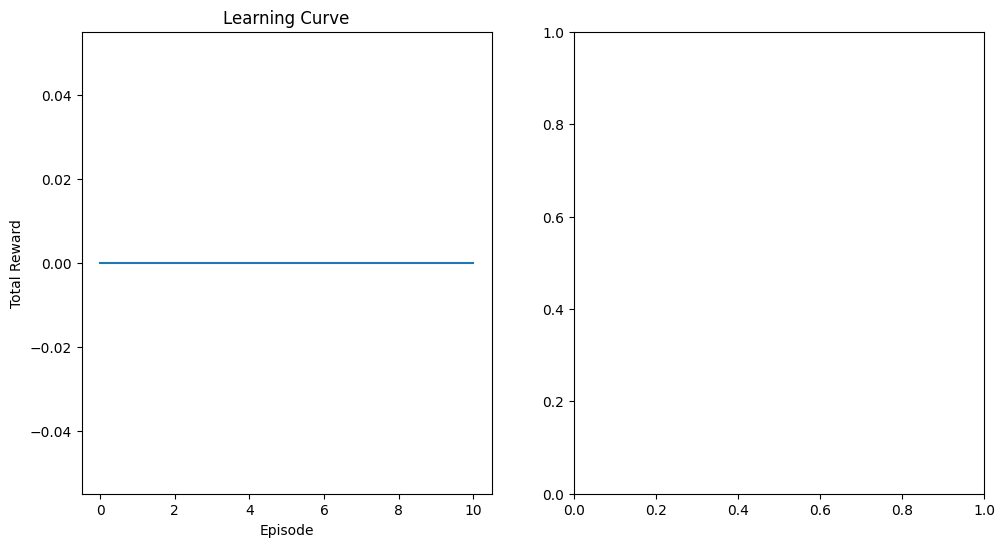

In [334]:
visualize_training_report(episode_rewards, evaluation_rewards, episode_profits, episodes=50)

In [335]:
# Evaluate the agent after training
average_reward = evaluate_agent(agent, env, episodes=10)
print(f"Average Evaluation Reward: {average_reward}")

Average Evaluation Reward: 0.0
